# Imports & Varaibles

In [5]:
import sys
import os
sys.path.append(os.path.abspath("."))

In [6]:
from pathlib import Path
import torch
from torch.utils.data import DataLoader
from model import DiagnosticModel
from data import DicomDataset, split_and_augment
from pytorch_grad_cam import GradCAM
import matplotlib.pyplot as plt
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_name = 'resnet50'
in_channels = 3
ckpt_path = Path('/data/vision/polina/users/marcusbl/bin_class/outputs/resnet50_no_mask/best_model.pth')

data_dir = Path('/data/vision/polina/users/marcusbl/data')
mask_method = 'stack'

# Load the Model from ckpt

In [8]:
checkpoint = torch.load(ckpt_path, map_location=device)
model = DiagnosticModel(model_name = model_name, in_channels = in_channels, include_weights = False)
model = model.to(device)

model.load_state_dict(checkpoint['model_state_dict'])

/tmp/ipykernel_1033572/4260082709.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location=device)


<All keys matched successfully>

# Load Some Data

In [9]:
batch_size = 6

In [ ]:
dataset = DicomDataset(data_dir, mask_method = mask_method, norm_method = 'min-max')
train_dataset, val_dataset = split_and_augment(dataset, val_ratio=0.2, aug_method='sc')

Loading People Data:   0%|          | 0/30 [00:00<?, ?it/s]

Loading People Data: 100%|██████████| 30/30 [00:06<00:00,  4.34it/s]

Applying Spatital Augmentations
Applying Color Augmentations


In [11]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle = True)

# Doing the GradCam

In [12]:
target_layers = [model.model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Displaying Results

In [13]:
def display_gradcam(inputs, labels, info: str):

    # Get Model Predictions
    outputs = model(inputs.to(device))
    _, preds = torch.max(outputs, dim=1)

    # Run GradCam
    grayscale_cam_labels = cam (
        input_tensor = inputs,
        targets = [ClassifierOutputTarget(label.item()) for label in labels]
    )
    grayscale_cam_preds = cam (
        input_tensor = inputs,
        targets = [ClassifierOutputTarget(pred.item()) for pred in preds]
    )



    # Display Results
    fig, ax = plt.subplots(3, batch_size, figsize = (13, 6))

    for i in range(batch_size):
        input_image = inputs[i].cpu().permute(1, 2, 0).numpy()
        input_image = (input_image - input_image.min()) / (input_image.max() - input_image.min())

        # Overlay the heatmap on the image
        visualization_label = show_cam_on_image(input_image, grayscale_cam_labels[i, :], use_rgb=True)
        visualization_pred = show_cam_on_image(input_image, grayscale_cam_preds[i, :], use_rgb=True)

        ax[0, i].imshow(input_image)
        ax[0, i].axis("off")
        ax[0, i].set_title(f"Label = {labels[i]}; Pred = {preds[i]}")

        # Plot Grad-CAM heatmap overlay for pred
        ax[1, i].imshow(visualization_pred)
        ax[1, i].axis("off")
        ax[1, i].set_title(f"Grad-CAM Pred")

        # Plot Grad-CAM heatmap overlay
        ax[2, i].imshow(visualization_label)
        ax[2, i].axis("off")
        ax[2, i].set_title(f"Grad-CAM Label")
    
    fig.suptitle(f"Grad-CAM Visualizations for {info}", fontsize=16, fontweight="bold")
    fig.tight_layout()
    plt.show()

def display_gradcam_repeat(info: str, k):
    iterator = iter(val_loader)
    for _ in range(k):
        inputs, labels = next(iterator)
        display_gradcam(inputs, labels, info)



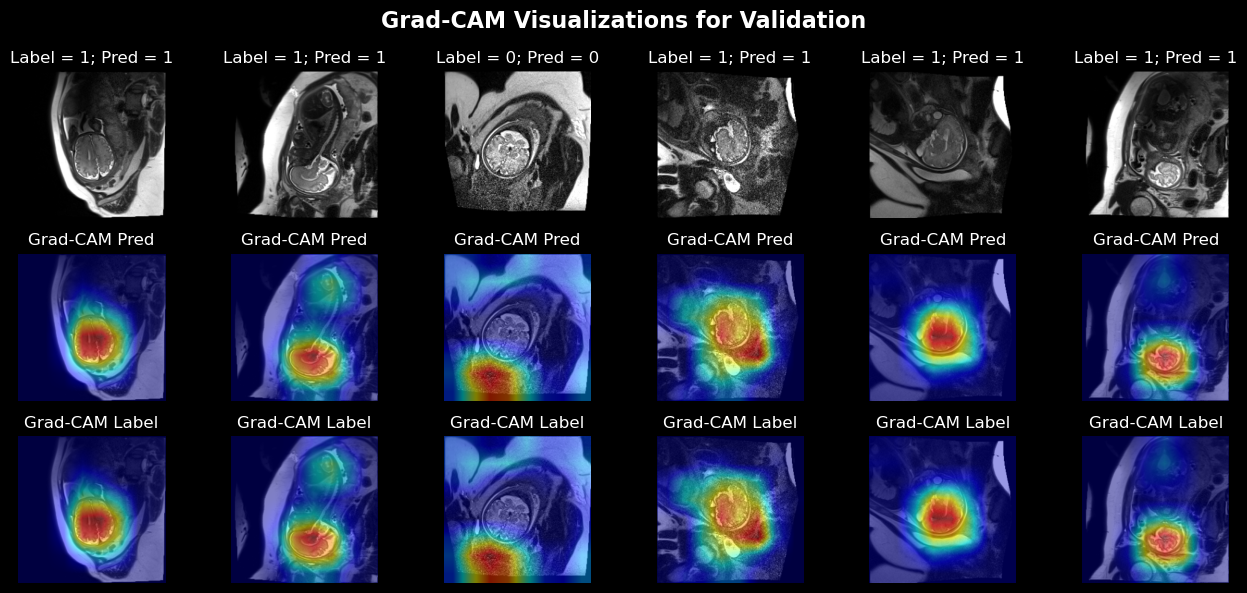

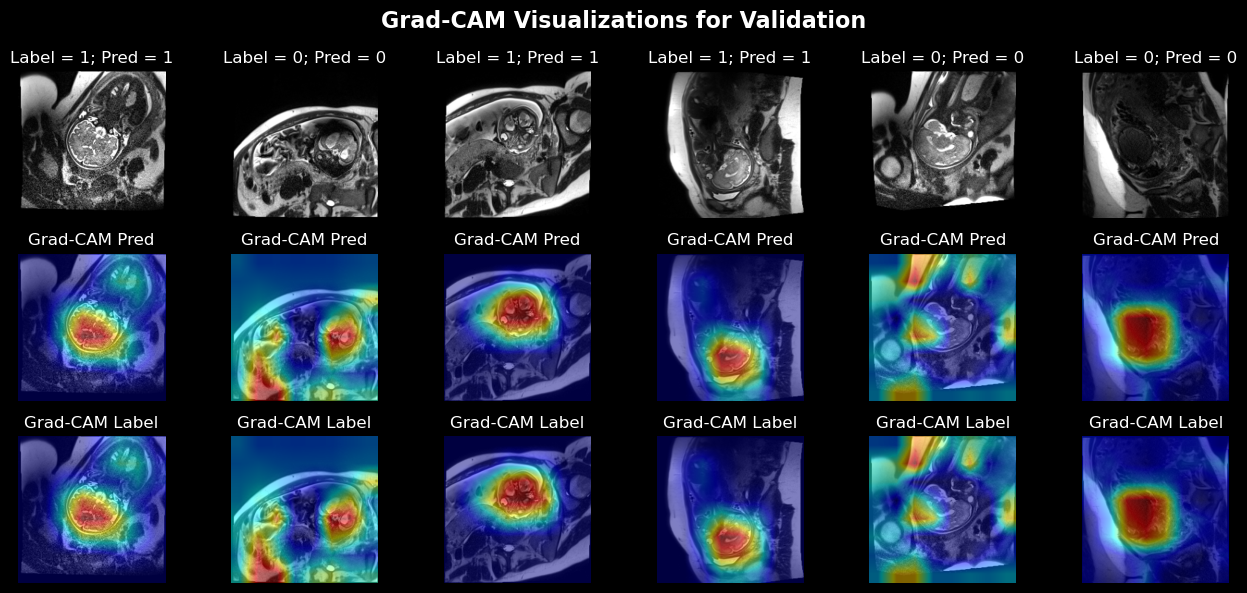

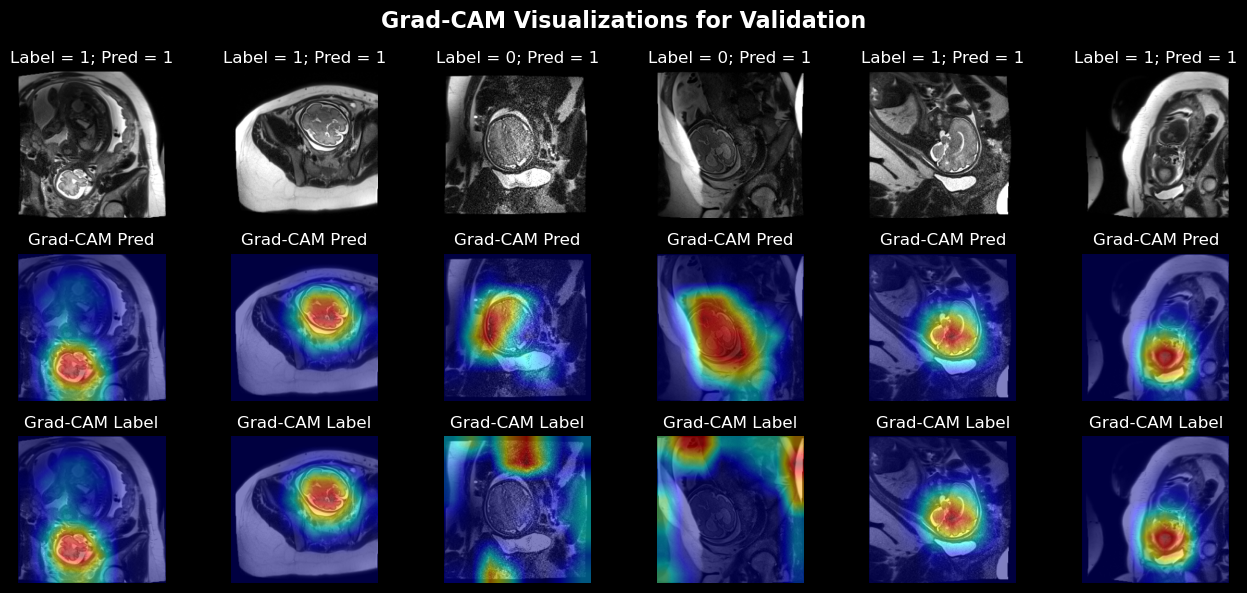

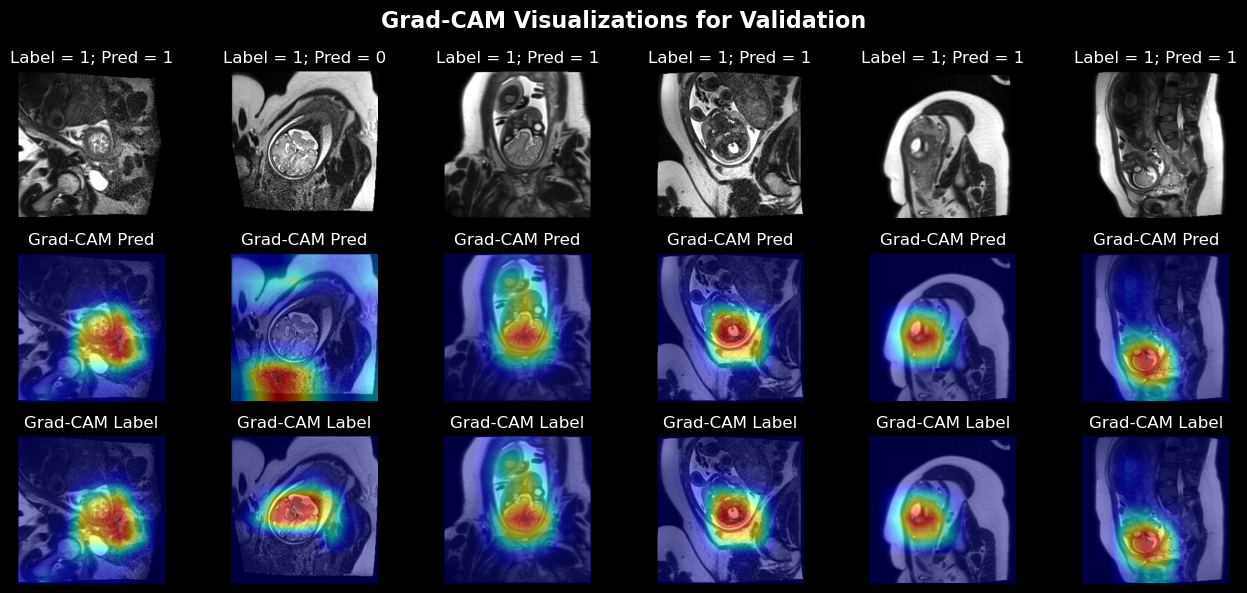

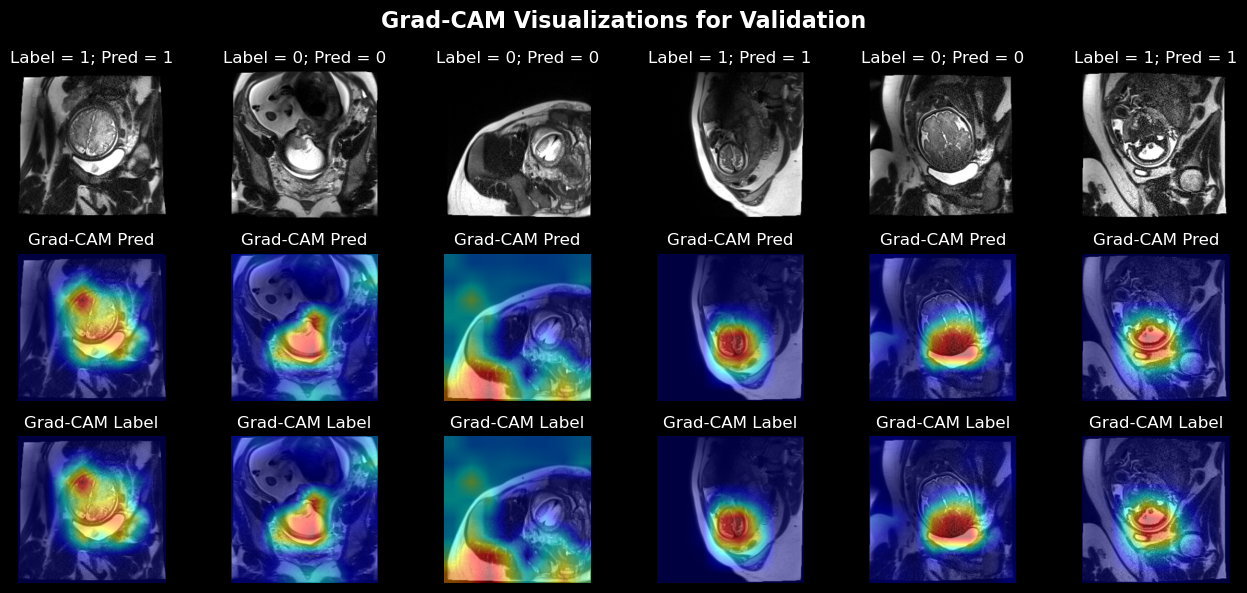

In [15]:
inputs, labels = next(iter(val_loader))
display_gradcam_repeat('Validation', k = 5)